## Check in #3 


task: 
Based on your PCA visualizations, your project goal, and your
chosen method: 
<br>
decide on a model to use (You will have a chance to make a better model next week, but feel
free to ask for guidance on choosing a model)
<br>
• Fit your model to your training dataset
<br>
• Predict the target variable in the validation dataset
<br>
• Next class we will discuss metrics to determine if your model
is performing well on the “unseen” data!

In [33]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

In [34]:
# Load metadata and expression data

data = pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)


train_data = pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

train_metadata = pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)


print("Expression data shape (genes x samples):", data.shape)
print("Metadata shape (samples x features):", metadata_df.shape)
print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Expression data shape (genes x samples): (15716, 1802)
Metadata shape (samples x features): (1802, 29)

Metadata columns:
['cancer_type', 'bcr_patient_barcode', 'gender', 'race', 'ethnicity', 'age_at_diagnosis', 'ajcc_pathologic_tumor_stage', 'ajcc_nodes_pathologic_pn', 'ajcc_metastasis_pathologic_pm', 'ajcc_tumor_pathologic_pt', 'tumor_status', 'histologic_diagnosis', 'history_other_malignancy', 'history_thyroid_disease', 'history_thyroid_disease_other', 'history_reflux_disease_indicator', 'history_hormonal_contraceptives_use', 'pregnancies_count_miscarriage', 'jewish_religion_heritage_indicator', 'tobacco_smoking_age_started', 'family_history_cancer_type', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time']


In [35]:
# Subset metadata to breast cancer
brca_metadata = metadata_df[metadata_df["cancer_type"] == "BRCA"].copy()
print("BRCA metadata shape:", brca_metadata.shape)

# Apoptosis / resisting apoptosis gene set
desired_gene_list = [
    "BCL2", "BCL2L1", "MCL1", "BAX", "BAK1",
    "TP53", "CASP3", "CASP8", "CASP9",
    "FAS", "FADD", "XIAP", "BIRC5",
    "BAD", "BID", "BBC3", "PMAIP1"
]

available_genes = [gene for gene in desired_gene_list if gene in data.index]
missing_genes = [gene for gene in desired_gene_list if gene not in data.index]

print("Number of requested genes:", len(desired_gene_list))
print("Number of genes found in dataset:", len(available_genes))
print("Genes found:", available_genes)
print("Missing genes:", missing_genes)

# Subset expression data to BRCA samples and apoptosis genes
brca_sample_ids = brca_metadata.index.intersection(data.columns)
brca_data = data.loc[available_genes, brca_sample_ids]

print("\nBRCA expression subset shape (genes x BRCA samples):", brca_data.shape)
brca_data.head()

BRCA metadata shape: (80, 29)
Number of requested genes: 17
Number of genes found in dataset: 17
Genes found: ['BCL2', 'BCL2L1', 'MCL1', 'BAX', 'BAK1', 'TP53', 'CASP3', 'CASP8', 'CASP9', 'FAS', 'FADD', 'XIAP', 'BIRC5', 'BAD', 'BID', 'BBC3', 'PMAIP1']
Missing genes: []

BRCA expression subset shape (genes x BRCA samples): (17, 80)


,TCGA-E9-A1NI-01A-11R-A14D-07,TCGA-E2-A1LK-01A-21R-A14D-07,TCGA-BH-A0B2-01A-11R-A10J-07,TCGA-E2-A107-01A-11R-A10J-07,TCGA-LL-A5YN-01A-11R-A28M-07,TCGA-BH-A0DQ-01A-11R-A084-07,TCGA-D8-A73X-01A-11R-A32P-07,TCGA-AR-A0TP-01A-11R-A084-07,TCGA-E2-A1IF-01A-11R-A144-07,TCGA-EW-A6SD-01A-12R-A33J-07,...,TCGA-D8-A1JA-01A-11R-A13Q-07,TCGA-A2-A0D0-01A-11R-A00Z-07,TCGA-A8-A07B-01A-11R-A00Z-07,TCGA-C8-A275-01A-21R-A16F-07,TCGA-AO-A1KQ-01A-11R-A13Q-07,TCGA-E9-A5UP-01A-11R-A28M-07,TCGA-AR-A24T-01A-11R-A169-07,TCGA-D8-A1XB-01A-11R-A14D-07,TCGA-E9-A245-01A-22R-A16F-07,TCGA-WT-AB44-01A-11R-A41B-07
BCL2,5.248282,0.985832,5.784362,4.152444,3.692885,4.763121,5.221591,5.376440,4.050835,1.936183,...,1.693603,1.996426,5.779014,2.672941,5.405569,5.532695,5.958578,6.085538,6.243730,1.873949
BCL2L1,7.818040,6.874837,7.115444,7.566785,6.954511,7.408560,7.460900,6.024670,6.833883,7.256705,...,7.514368,6.689359,6.784440,7.055031,7.299693,8.759745,7.486974,7.529951,6.777458,6.381661
MCL1,7.816182,8.140580,8.165650,8.071209,7.278051,8.035222,8.193623,7.856121,8.412290,8.395989,...,9.078687,8.175704,8.279657,8.363384,7.513230,8.424985,8.756147,8.547165,7.503071,8.404597
BAX,6.720700,7.189939,6.504814,7.466535,7.662465,6.634294,6.585344,5.994697,7.414525,6.308539,...,5.301869,6.917972,6.257364,6.167569,7.180470,7.320232,5.802379,6.468790,5.992391,6.350984
BAK1,4.584133,5.334564,4.855286,4.845804,5.442022,5.610309,4.346540,4.705020,4.831672,4.301206,...,4.254277,5.583720,4.708609,5.048889,4.169633,4.340381,4.749268,4.740960,3.371286,3.386362


In [36]:
# Transpose so rows = samples and columns = genes
X = brca_data.T

# Standardize the expression values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
pca_df = pca_df.join(brca_metadata)

# Add one key gene for coloring
if "BCL2" in X.columns:
    pca_df["BCL2_expression"] = X["BCL2"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio:
[0.1987766  0.15712808]


,PC1,PC2,cancer_type,bcr_patient_barcode,gender,race,ethnicity,age_at_diagnosis,ajcc_pathologic_tumor_stage,ajcc_nodes_pathologic_pn,...,family_history_cancer_type,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,BCL2_expression
TCGA-E9-A1NI-01A-11R-A14D-07,-0.246504,0.978967,BRCA,TCGA-E9-A1NI,FEMALE,WHITE,NOT HISPANIC OR LATINO,51.0,Stage IIA,N0,...,NaN,0.0,300.0,0.0,300.0,0.0,300.0,0.0,300.0,5.248282
TCGA-E2-A1LK-01A-21R-A14D-07,-5.239930,-1.590538,BRCA,TCGA-E2-A1LK,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,84.0,Stage IIIC,N3a,...,NaN,1.0,266.0,1.0,266.0,1.0,155.0,1.0,155.0,0.985832
TCGA-BH-A0B2-01A-11R-A10J-07,0.263982,-0.156312,BRCA,TCGA-BH-A0B2,FEMALE,WHITE,NOT HISPANIC OR LATINO,43.0,Stage I,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.784362
TCGA-E2-A107-01A-11R-A10J-07,-1.693936,1.653981,BRCA,TCGA-E2-A107,FEMALE,WHITE,NOT HISPANIC OR LATINO,54.0,Stage IIIA,N2a,...,NaN,0.0,1047.0,0.0,1047.0,0.0,1047.0,0.0,1047.0,4.152444
TCGA-LL-A5YN-01A-11R-A28M-07,-3.004212,1.201851,BRCA,TCGA-LL-A5YN,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,46.0,Stage IIA,N0 (i-),...,NaN,0.0,447.0,0.0,447.0,0.0,447.0,0.0,447.0,3.692885


In [ ]:



train_metadata = train_metadata[train_metadata["cancer_type"] == "BRCA"].copy()

# Apoptosis genes
genes = [
    "BCL2","BCL2L1","MCL1","BAX","BAK1",
    "TP53","CASP3","CASP8","CASP9",
    "FAS","FADD","XIAP","BIRC5",
    "BAD","BID","BBC3","PMAIP1"
]

genes = [g for g in genes if g in train_data.index]

# Match samples
train_ids = train_metadata.index.intersection(train_data.columns)
train_expr = train_data.loc[genes, train_ids]

X_train = train_expr.T



def simplify_stage(stage):
    if pd.isna(stage):
        return np.nan
    s = str(stage).upper()
    if "I" in s and not ("III" in s or "IV" in s):
        return "Early"
    elif "II" in s and not ("III" in s or "IV" in s):
        return "Early"
    elif "III" in s or "IV" in s:
        return "Late"
    return np.nan

train_metadata["stage_group"] = train_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

# Filter valid labels
valid_idx = train_metadata["stage_group"].isin(["Early", "Late"])
X_train = X_train.loc[valid_idx]
y_train = train_metadata.loc[valid_idx, "stage_group"].map({"Early":0, "Late":1})



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)



model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Training complete.")



val_data = pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

val_metadata = pd.read_csv(
    '/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/VALIDATION_SET_GSE62944_metadata.csv',
    index_col=0
)


val_metadata = val_metadata[val_metadata["cancer_type"] == "BRCA"].copy()

val_ids = val_metadata.index.intersection(val_data.columns)
val_expr = val_data.loc[genes, val_ids]

X_val = val_expr.T


X_val_scaled = scaler.transform(X_val)



val_pred = model.predict(X_val_scaled)

val_pred_labels = pd.Series(val_pred, index=X_val.index).map({0:"Early", 1:"Late"})



print("\nValidation Prediction Counts:")
print(val_pred_labels.value_counts())

print("\nFirst 10 Predictions:")
print(val_pred_labels.head(10))

Training complete.

Validation Prediction Counts:
Early    45
Late     35
Name: count, dtype: int64

First 10 Predictions:
TCGA-E9-A1R0-01A-22R-A16F-07    Early
TCGA-E2-A1LG-01A-21R-A14M-07    Early
TCGA-BH-A0AW-01A-11R-A056-07    Early
TCGA-D8-A3Z6-01A-11R-A239-07    Early
TCGA-LL-A441-01A-11R-A24H-07     Late
TCGA-BH-A0DG-01A-21R-A12P-07     Late
TCGA-D8-A3Z5-01A-41R-A24H-07    Early
TCGA-AO-A12H-01A-11R-A115-07    Early
TCGA-E2-A1B6-01A-31R-A12P-07    Early
TCGA-GI-A2C9-01A-11R-A21T-07    Early
dtype: object


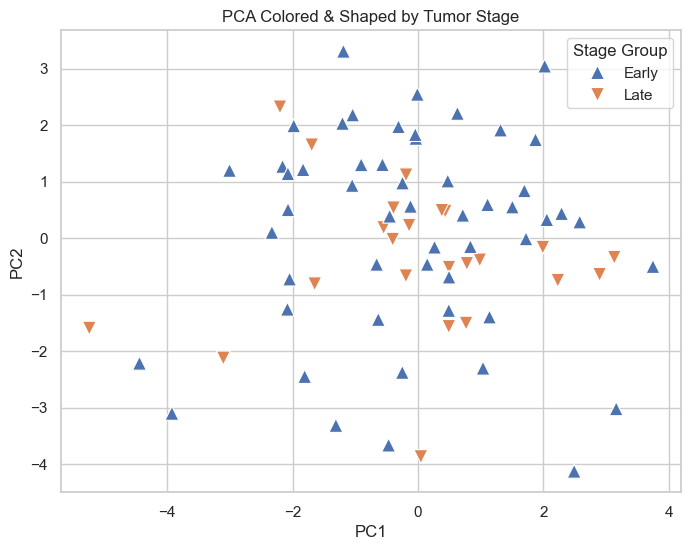

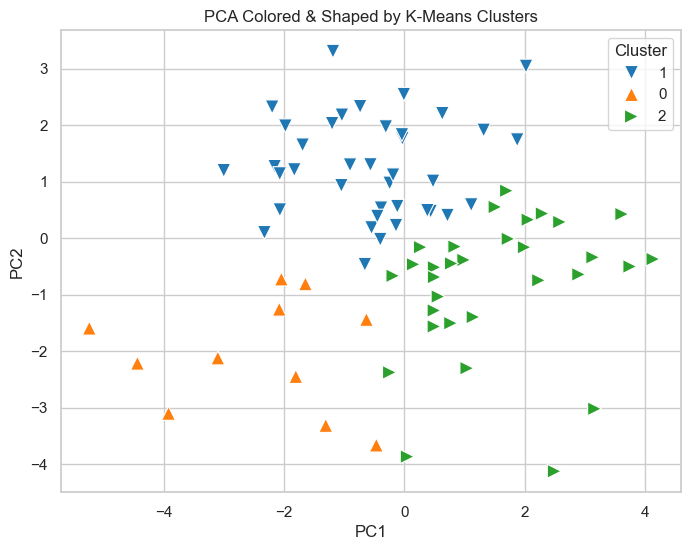

In [ ]:

def simplify_stage(stage):
    if pd.isna(stage):
        return np.nan
    s = str(stage).upper()
    if "I" in s and not ("III" in s or "IV" in s):
        return "Early"
    elif "II" in s and not ("III" in s or "IV" in s):
        return "Early"
    elif "III" in s or "IV" in s:
        return "Late"
    return np.nan

pca_df["stage_group"] = pca_df["ajcc_pathologic_tumor_stage"].apply(simplify_stage)


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="stage_group",
    style="stage_group",
    markers={"Early": "^", "Late": "v"},  # ▲ and ▼ triangles
    s=100
)
plt.title("PCA Colored & Shaped by Tumor Stage")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Stage Group")
plt.show()


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df["cluster"] = kmeans.fit_predict(X_scaled).astype(str)


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    style="cluster",
    markers={"0": "^", "1": "v", "2": ">"},  # different triangle directions
    palette="tab10",
    s=100
)
plt.title("PCA Colored & Shaped by K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()